# Οπτικοποίηση Επίδοσης Φοιτητών στις Εξετάσεις με Τρισδιάστατες Επιφάνειες και Διαγράμματα Διασποράς (PROC G3D)

## Σύνοψη για Στελέχη

Αυτό το notebook χρησιμοποιεί το **PROC G3D** για να οπτικοποιήσει πώς δύο παράγοντες διδακτικής
παρέμβασης διαμορφώνουν από κοινού τις επιδόσεις φοιτητών σε ένα περιβάλλον εκπαιδευτικής
ανάλυσης. Ένα πλήρες παραγοντικό πλέγμα οδηγεί μια ομαλή **επιφάνεια** απόκρισης προβλεπόμενων
βαθμολογιών εξέτασης ως προς τις εβδομαδιαίες ώρες μελέτης (0 έως 20) και τον προηγούμενο μέσο όρο
(GPA) (0 έως 4), και μια συνθετική ομάδα 100 φοιτητών αποδίδεται ως πάνελ **τρισδιάστατης
διασποράς** χωρισμένα ανά ομάδα επίδοσης.

Η προσαρμοσμένη επιφάνεια ανεβαίνει από μια προβλεπόμενη βαθμολογία κοντά στο 26 με μηδέν ώρες
μελέτης προς ένα ανώτατο όριο κοντά στο 99, ισοπεδώνοντας καθώς οι ώρες μελέτης ξεπερνούν
περίπου τις 10 — η κορυφογραμμή φθίνουσας απόδοσης που κωδικοποιεί το μοντέλο. Τα πάνελ φοιτητών
επιβεβαιώνουν το πρότυπο σε ατομικό επίπεδο: οι 20 φοιτητές *Άριστοι* (ο καθένας με βαθμολογία 85
ή περισσότερο) βρίσκονται στη γωνία υψηλού GPA και υψηλότερης μελέτης, ενώ οι 33 φοιτητές *Σε
Κίνδυνο* συγκεντρώνονται στην περιοχή χαμηλής προσπάθειας και χαμηλού GPA. Μια όψη φιλτραρισμένη
με WHERE σε αυτή τη γωνία απομονώνει 35 φοιτητές για τους οποίους μέτριες αυξήσεις στον χρόνο
μελέτης προσφέρουν τα μεγαλύτερα οριακά οφέλη.


## Πηγές Δεδομένων

Όλα τα δεδομένα δημιουργούνται εντός του προγράμματος με `call streaminit()` και `rand()` — χωρίς
εξωτερικά αρχεία ή πρόσβαση στο δίκτυο.

**`score_grid`** — πλήρες παραγοντικό πλέγμα που οδηγεί την επιφάνεια απόκρισης (μία γραμμή ανά
κελί ωρών μελέτης x προηγούμενου GPA, 99 γραμμές).

| Μεταβλητή | Τύπος | Περιγραφή |
|----------|------|-------------|
| `study_hours` | Αριθμ. | Εβδομαδιαίες ώρες αυτομελέτης, 0 έως 20 ανά 2 (άξονας Χ) |
| `prior_gpa` | Αριθμ. | Προηγούμενος μέσος όρος (GPA) σε κλίμακα 0–4, 0 έως 4 ανά 0,5 (άξονας Y) |
| `pred_score` | Αριθμ. | Μοντελοποιημένη τελική βαθμολογία εξέτασης 0–100 από κορεσμένο μοντέλο απόκρισης (άξονας Z) |

**`students`** — συνθετική ατομική ομάδα φοιτητών για τη διασπορά (100 γραμμές).

| Μεταβλητή | Τύπος | Περιγραφή |
|----------|------|-------------|
| `student_id` | Αριθμ. | Διαδοχικό αναγνωριστικό φοιτητή |
| `study_hours` | Αριθμ. | Παρατηρηθείσες εβδομαδιαίες ώρες μελέτης (άξονας Χ) |
| `prior_gpa` | Αριθμ. | Παρατηρηθείς προηγούμενος GPA (άξονας Y) |
| `exam_score` | Αριθμ. | Παρατηρηθείσα τελική βαθμολογία εξέτασης 0–100 (άξονας Z) |
| `cohort` | Χαρακτ. | Ομάδα εισαγωγής, `Φθινόπωρο` ή `Άνοιξη` |
| `band` | Χαρακτ. | Ομάδα επίδοσης: `Άριστοι` (≥85), `Επιτυχόντες` (65–84), `Σε Κίνδυνο` (<65) |

Το πλέγμα έχει σκόπιμα μέγεθος 99 κελιών ώστε να καλύπτει το πλήρες εύρος 0–20 ωρών μελέτης και
0–4 GPA παραμένοντας εντός του ορίου 100 παρατηρήσεων αυτού του περιβάλλοντος· ένα πλέγμα 11 x 9
διατηρεί την επιφάνεια ομαλή χωρίς περικοπή κανενός άξονα.


# Οπτικοποίηση της Επίδοσης Φοιτητών στις Εξετάσεις με το PROC G3D

Οι ερευνητές εκπαίδευσης συχνά θέλουν να κατανοήσουν πώς δύο μεταβλητοί παράγοντες οδηγούν από
κοινού ένα αποτέλεσμα. Εδώ ρωτάμε: *πώς συνδυάζονται οι εβδομαδιαίες ώρες μελέτης και ο
προηγούμενος GPA ενός φοιτητή για να διαμορφώσουν την τελική επίδοση στην εξέταση;*

Ένα δισδιάστατο διάγραμμα δεν μπορεί να δείξει μια επιφάνεια αλληλεπίδρασης. Το **PROC G3D**
σχεδιάζει πραγματικά τρισδιάστατα γραφήματα από μεταβλητές σε σημειογραφία `y*x=z`, όπου τα Χ και
Y εκτείνονται στο οριζόντιο επίπεδο και το Z ανεβαίνει κατακόρυφα. Χρησιμοποιούμε δύο από τις
δυνατότητές του:

- **PLOT** — μια συνεχής *επιφάνεια* απόκρισης πάνω σε ένα πλήρες πλέγμα των δύο προβλεπτών.
- **SCATTER** — μεμονωμένοι φοιτητές σχεδιασμένοι ως τρισδιάστατα σύμβολα. Αποδίδουμε ένα πάνελ
  ανά ομάδα επίδοσης, το καθένα με το δικό του χρώμα και σχήμα δείκτη, ώστε τα τρία επίπεδα
  αποτελέσματος να συγκρίνονται εύκολα.

Όλα τα παρακάτω εκτελούνται πάνω σε συνθετικά δεδομένα που δημιουργούνται εντός του προγράμματος,
οπότε το notebook είναι πλήρως αυτόνομο.


## Βήμα 1 — Δημιουργία του πλέγματος επιφάνειας απόκρισης

Ένα διάγραμμα επιφάνειας G3D χρειάζεται ένα αρκετά πλήρες πλέγμα: απαιτεί μη ελλείπουσες τιμές Z
για τουλάχιστον τα μισά κελιά X-Y. Εξασφαλίζουμε ένα *πλήρες* πλέγμα φωλιάζοντας δύο βρόχους `DO`
πάνω στις `study_hours` (0 έως 20 ανά 2) και το `prior_gpa` (0 έως 4 ανά 0,5) — ένα πλέγμα 11 x 9
από 99 κελιά που καλύπτει πλήρως και τους δύο άξονες.

Η προβλεπόμενη βαθμολογία ακολουθεί ένα εύλογο κορεσμένο μοντέλο: οι αποδόσεις από τη μελέτη
φθίνουν σε υψηλές ώρες, ο προηγούμενος GPA συνεισφέρει περίπου γραμμικά, και οι δύο
αλληλεπιδρούν (ένας ισχυρός φοιτητής μετατρέπει τον χρόνο μελέτης σε βαθμούς πιο αποτελεσματικά).
Ένας μικρός αναπαραγώγιμος θόρυβος από το `rand('NORMAL')` εμποδίζει την επιφάνεια να φαίνεται
τέλεια αναλυτική. Το `call streaminit()` καθορίζει τον σπόρο ώστε το πλέγμα να είναι αναπαραγώγιμο.


In [1]:
ΔΕΔΟΜΕΝΑ score_grid;
   CALL streaminit(20260531);
   ΕΠΑΝΑΛΗΨΗ study_hours = 0 ΕΩΣ 20 ΚΑΤΑ 2;     /* 11 τιμές: πλήρες εύρος 0-20 */
      ΕΠΑΝΑΛΗΨΗ prior_gpa = 0 ΕΩΣ 4 ΚΑΤΑ 0.5;   /* 9 τιμές  -> 99 κελιά πλέγματος */
         /* κορεσμένη απόδοση στις ώρες μελέτης */
         effort = 40 * (1 - EXP(-study_hours / 6));
         /* προηγούμενη επίδοση και ένας όρος αλληλεπίδρασης */
         BASE   = 8 * prior_gpa;
         inter  = 1.1 * prior_gpa * (1 - EXP(-study_hours / 6));
         pred_score = 25 + effort + BASE + inter
                      + rand('NORMAL') * 1.5;
         ΕΑΝ pred_score > 100 ΤΟΤΕ pred_score = 100;
         ΕΑΝ pred_score < 0   ΤΟΤΕ pred_score = 0;
         ΕΞΟΔΟΣ;
      ΤΕΛΟΣ;
   ΤΕΛΟΣ;
   ΚΡΑΤΗΣΗ study_hours prior_gpa pred_score;
   ΕΤΙΚΕΤΑ study_hours = 'Ώρες Μελέτης'
         prior_gpa   = 'Προηγούμενος GPA'
         pred_score  = 'Προβλεπόμενη Βαθμολογία';
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=score_grid n MIN mean MAX maxdec=1;
   ΜΕΤΑΒΛΗΤΗ study_hours prior_gpa pred_score;
ΕΚΤΕΛΕΣΗ;


                                                  The MEANS Procedure

 Variable     Label                                                N     Minimum        Mean     Maximum
 -------------------------------------------------------------------------------------------------------
 study_hours  Ώρες Μελέτης                                        99         0.0        10.0        20.0
 prior_gpa    Προηγούμενος GPA                                    99         0.0         2.0         4.0
 pred_score   Προβλεπόμενη Βαθμολογία                             99        25.7        70.0        98.7
 -------------------------------------------------------------------------------------------------------




NOTE: DATA score_grid


NOTE: Wrote score_grid (99 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Βήμα 2 — Σχεδίαση της βασικής επιφάνειας απόκρισης

Με ένα πλήρες πλέγμα στη διάθεσή μας, η απλούστερη κλήση σχεδιάζει την επιφάνεια χρησιμοποιώντας
τις προεπιλογές της διαδικασίας. Η σύνταξη `PLOT y*x=z` αντιστοιχίζει το `prior_gpa` στον άξονα Y,
τις `study_hours` στον άξονα X, και την προβλεπόμενη βαθμολογία στον κατακόρυφο άξονα Z.

Επισημαίνουμε τους άξονες με μια δήλωση `LABEL` και ορίζουμε τίτλους και υποσημείωση με τις
καθολικές δηλώσεις `TITLE`/`FOOTNOTE` ώστε το γράφημα να διαβάζεται καθαρά.


                                  Επιφάνεια Προβλεπόμενης Βαθμολογίας Τελικής Εξέτασης                                  
                                Επίδραση Εβδομαδιαίων Ωρών Μελέτης και Προηγούμενου GPA                                 

PROC G3D Output
Data: score_grid

Variables: Εβδομαδιαίες Ώρες Μελέτης, Προηγούμενος GPA, Προβλεπόμενη Βαθμολογία Εξέτασης

                       Εβδομαδιαίες Ώρες Μελέτης              Προηγούμενος GPA                                Προβλεπόμενη Βαθμολογία Εξέτασης
------------------------------------------------  ----------------------------  --------------------------------------------------------------
                                               0                             0                                                   25.7031536911
                                               0                           0.5                                                   28.9516502743
                                               0             


NOTE: GOPTIONS RESET=GLOBAL (unrecognized, treating as GOPTIONS).
NOTE: GOPTIONS BORDER enabled.
NOTE: Option TITLE changed to Επιφάνεια Προβλεπόμενης Βαθμολογίας Τελικής Εξέτασης.
NOTE: Option TITLE2 changed to Επίδραση Εβδομαδιαίων Ωρών Μελέτης και Προηγούμενου GPA.
NOTE: Option FOOTNOTE changed to Συνθετικά δεδομένα εκπαιδευτικής ανάλυσης .
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: g3d_surface.spec.json


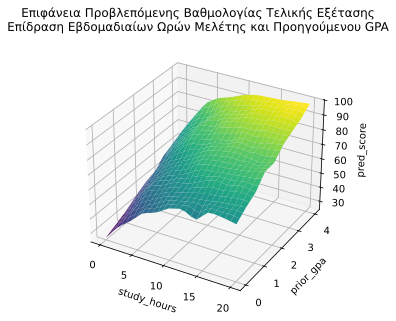

In [2]:
GOPTIONS reset=GLOBAL BORDER;

TITLE 'Επιφάνεια Προβλεπόμενης Βαθμολογίας Τελικής Εξέτασης';
title2 'Επίδραση Εβδομαδιαίων Ωρών Μελέτης και Προηγούμενου GPA';
footnote j=r 'Συνθετικά δεδομένα εκπαιδευτικής ανάλυσης ';

ΔΙΑΔΙΚΑΣΙΑ g3d ΔΕΔΟΜΕΝΑ=score_grid;
   PLOT prior_gpa*study_hours=pred_score;
   ΕΤΙΚΕΤΑ study_hours = 'Εβδομαδιαίες Ώρες Μελέτης'
         prior_gpa   = 'Προηγούμενος GPA'
         pred_score  = 'Προβλεπόμενη Βαθμολογία Εξέτασης';
ΕΚΤΕΛΕΣΗ;
QUIT;


## Βήμα 3 — Βελτίωση της επιφάνειας με επιλογές προβολής και αξόνων

Λίγες επιλογές κάνουν την επιφάνεια πολύ πιο ευανάγνωστη:

- **ROTATE=** και **TILT=** ορίζουν τη γωνία προβολής (μοίρες γύρω από τον άξονα Z, και κλίση
  προς τον θεατή).
- **XYTYPE=2** σχεδιάζει γραμμές επιφάνειας παράλληλες στον άξονα Y, τονίζοντας πώς η βαθμολογία
  ανεβαίνει με τις ώρες μελέτης.
- **SIDE** προσθέτει έναν πλευρικό τοίχο για μια συμπαγή, γλυπτική εμφάνιση.
- **GRID** προσθέτει γραμμές αναφοράς στις κύριες υποδιαιρέσεις.
- **ZMIN=/ZMAX=** και η οικογένεια **ZTICKNUM=** καθηλώνουν τον άξονα βαθμολογίας στο πλήρες εύρος
  0–100 ώστε η επιφάνεια να μην εμφανίζεται υπερβολική οπτικά, ενώ τα **XTICKNUM=/YTICKNUM=**
  ελέγχουν τις υποδιαιρέσεις του επιπέδου βάσης.
- **NAME=** και **DESCRIPTION=** επισημαίνουν το γράφημα στον κατάλογο εξόδου.


                                 Επιφάνεια Βαθμολογίας Εξέτασης (Διαμορφωμένη Προβολή)                                  
                                        Περιστροφή, Κλίση, και Κλιμάκωση Αξόνων                                         

PROC G3D Output
Data: score_grid

Variables: Εβδομαδιαίες Ώρες Μελέτης, Προηγούμενος GPA, Προβλεπόμενη Βαθμολογία Εξέτασης

                       Εβδομαδιαίες Ώρες Μελέτης              Προηγούμενος GPA                                Προβλεπόμενη Βαθμολογία Εξέτασης
------------------------------------------------  ----------------------------  --------------------------------------------------------------
                                               0                             0                                                   25.7031536911
                                               0                           0.5                                                   28.9516502743
                                               0             


NOTE: Option TITLE changed to Επιφάνεια Βαθμολογίας Εξέτασης (Διαμορφωμένη Προβολή).
NOTE: Option TITLE2 changed to Περιστροφή, Κλίση, και Κλιμάκωση Αξόνων.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: scoresurf.spec.json


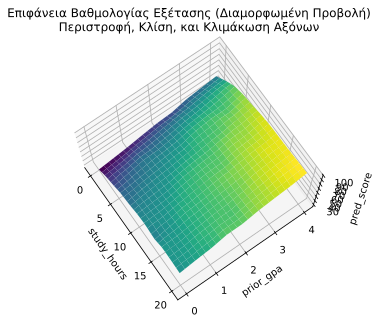

In [3]:
TITLE 'Επιφάνεια Βαθμολογίας Εξέτασης (Διαμορφωμένη Προβολή)';
title2 'Περιστροφή, Κλίση, και Κλιμάκωση Αξόνων';

ΔΙΑΔΙΚΑΣΙΑ g3d ΔΕΔΟΜΕΝΑ=score_grid;
   PLOT prior_gpa*study_hours=pred_score /
        ROTATE=55
        tilt=75
        xytype=2
        side
        grid
        zmin=0 zmax=100
        xticknum=5 yticknum=5 zticknum=6
        name="scoresurf"
        description="Διαμορφωμένη επιφάνεια απόκρισης βαθμολογίας εξέτασης";
   ΕΤΙΚΕΤΑ study_hours = 'Εβδομαδιαίες Ώρες Μελέτης'
         prior_gpa   = 'Προηγούμενος GPA'
         pred_score  = 'Προβλεπόμενη Βαθμολογία Εξέτασης';
ΕΚΤΕΛΕΣΗ;
QUIT;


## Βήμα 4 — Σύγκριση της επιφάνειας από διάφορες γωνίες προβολής

Επειδή μια τρισδιάστατη επιφάνεια μπορεί να κρύψει δομή πίσω από τις δικές της κορυφές, βοηθάει
να αποδοθεί η ίδια επιφάνεια από περισσότερες από μία περιστροφές. Εδώ εκδίδουμε τρία βήματα PROC
G3D που μοιράζονται σταθερή κλίση αλλά μεταβάλλουν τη γωνία **ROTATE=** μέσα από τις 30, 90, και
150 μοίρες, ώστε η κορυφογραμμή να μπορεί να εξεταστεί από μπροστά, από το πλάι, και από πίσω.


                                                  Επιφάνεια Απόκρισης                                                   
                                              ROTATE = 30 σε Σταθερή Κλίση                                              

PROC G3D Output
Data: score_grid

Variables: Εβδομαδιαίες Ώρες Μελέτης, Προηγούμενος GPA, Προβλεπόμενη Βαθμολογία Εξέτασης

                       Εβδομαδιαίες Ώρες Μελέτης              Προηγούμενος GPA                                Προβλεπόμενη Βαθμολογία Εξέτασης
------------------------------------------------  ----------------------------  --------------------------------------------------------------
                                               0                             0                                                   25.7031536911
                                               0                           0.5                                                   28.9516502743
                                               0             


NOTE: Option TITLE changed to Επιφάνεια Απόκρισης.
NOTE: Option TITLE2 changed to ROTATE = 30 σε Σταθερή Κλίση.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: surf_rot30.spec.json
NOTE: Option TITLE changed to Επιφάνεια Απόκρισης.
NOTE: Option TITLE2 changed to ROTATE = 90 σε Σταθερή Κλίση.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: surf_rot90.spec.json
NOTE: Option TITLE changed to Επιφάνεια Απόκρισης.
NOTE: Option TITLE2 changed to ROTATE = 150 σε Σταθερή Κλίση.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: surf_rot150.spec.json


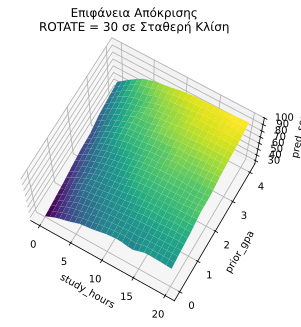

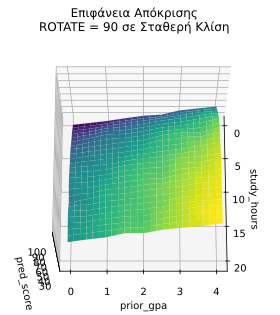

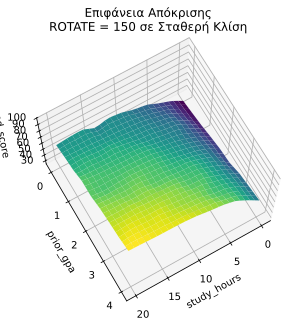

In [4]:
%macro angle(deg);
   TITLE 'Επιφάνεια Απόκρισης';
   title2 "ROTATE = &deg σε Σταθερή Κλίση";
   ΔΙΑΔΙΚΑΣΙΑ g3d ΔΕΔΟΜΕΝΑ=score_grid;
      PLOT prior_gpa*study_hours=pred_score /
           ROTATE=&deg
           tilt=70
           xytype=3
           zmin=0 zmax=100
           name="surf_rot&deg";
      ΕΤΙΚΕΤΑ study_hours = 'Εβδομαδιαίες Ώρες Μελέτης'
            prior_gpa   = 'Προηγούμενος GPA'
            pred_score  = 'Προβλεπόμενη Βαθμολογία Εξέτασης';
   ΕΚΤΕΛΕΣΗ;
   QUIT;
%mend;

%angle(30);
%angle(90);
%angle(150);


## Βήμα 5 — Δημιουργία συνθετικής ομάδας φοιτητών

Η επιφάνεια είναι ένα μοντέλο· οι πραγματικοί φοιτητές διασκορπίζονται γύρω της. Τώρα προσομοιώνουμε
100 μεμονωμένους φοιτητές από δύο ομάδες εισαγωγής (`Φθινόπωρο`, `Άνοιξη`). Κάθε φοιτητής έχει
παρατηρηθείσες ώρες μελέτης, έναν προηγούμενο GPA, και μια θορυβώδη πραγματοποιημένη βαθμολογία
εξέτασης που παράγεται από την ίδια λογική απόκρισης συν μεγαλύτερη ατομική μεταβλητότητα.

Στη συνέχεια παράγουμε μια ομάδα **επίδοσης** από τη βαθμολογία εξέτασης: `Άριστοι` (85 ή
περισσότερο), `Επιτυχόντες` (65 έως 84), και `Σε Κίνδυνο` (κάτω από 65). Η διασταύρωση PROC FREQ
παρακάτω αναφέρει πώς κατανέμονται οι ομάδες στις δύο ομάδες εισαγωγής. Οι `rand('UNIFORM')` και
`rand('NORMAL')` παρέχουν την τυχαιότητα· ο σπόρος διατηρεί την αναπαραγωγιμότητα.


                                                  Επιφάνεια Απόκρισης                                                   
                                             ROTATE = 150 σε Σταθερή Κλίση                                              

                                                   The FREQ Procedure

                                            Cumulative
Ομάδα Επίδοσης                 Frequency    Frequency
---------------------------------------------------------
Άριστοι                               20           20
Επιτυχόντες                           47           67
Σε Κίνδυνο                            33          100

Table of Ομάδα Εισαγωγής by Ομάδα Επίδοσης

Ομάδα Εισαγωγής               |               Άριστοι |           Επιτυχόντες |            Σε Κίνδυνο |                  Total
------------------------------+-----------------------+-----------------------+-----------------------+-----------------------
Άνοιξη                        |                    14 |   


NOTE: DATA students


NOTE: Wrote students (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_band.spec.json
NOTE: ODS plot written: freq_mosaic_cohort_band.spec.json
NOTE: PROC FREQ statement used.


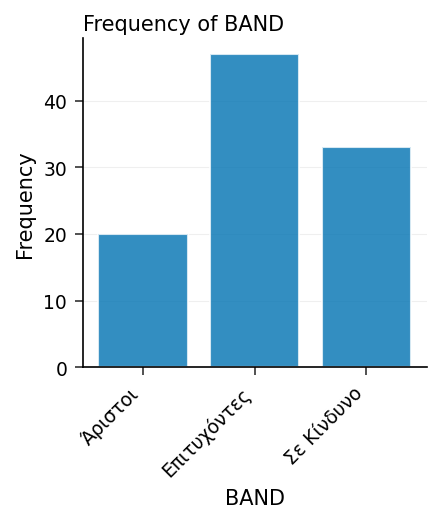

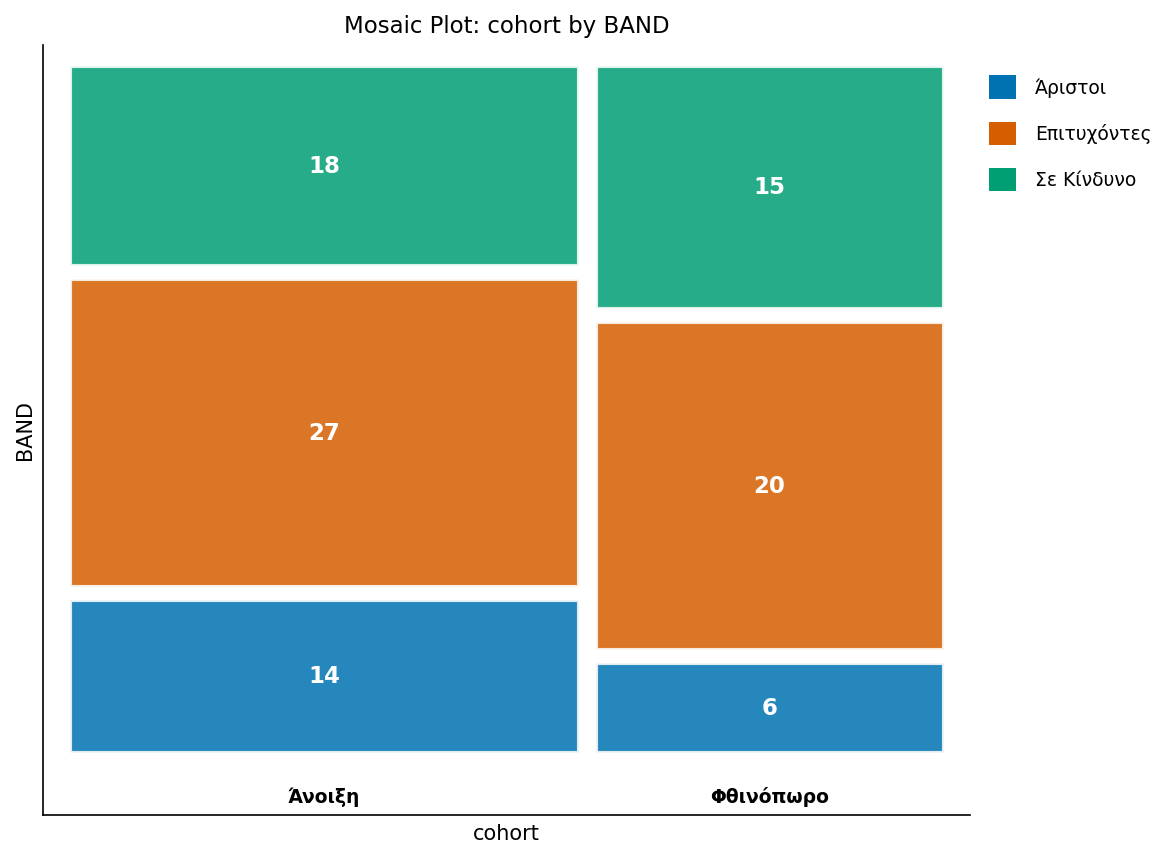

In [5]:
ΔΕΔΟΜΕΝΑ students;
   CALL streaminit(99001);
   LENGTH cohort $20 BAND $30;
   ΕΠΑΝΑΛΗΨΗ student_id = 1 ΕΩΣ 100;
      ΕΑΝ rand('UNIFORM') < 0.5 ΤΟΤΕ cohort = 'Φθινόπωρο';
      ΑΛΛΙΩΣ cohort = 'Άνοιξη';

      study_hours = 20 * rand('UNIFORM');
      prior_gpa   = 4  * rand('UNIFORM');

      effort = 40 * (1 - EXP(-study_hours / 6));
      BASE   = 8 * prior_gpa;
      inter  = 1.1 * prior_gpa * (1 - EXP(-study_hours / 6));
      exam_score = 25 + effort + BASE + inter
                   + rand('NORMAL') * 7;
      ΕΑΝ exam_score > 100 ΤΟΤΕ exam_score = 100;
      ΕΑΝ exam_score < 0   ΤΟΤΕ exam_score = 0;

      ΕΑΝ exam_score >= 85 ΤΟΤΕ BAND = 'Άριστοι';
      ΑΛΛΙΩΣ ΕΑΝ exam_score >= 65 ΤΟΤΕ BAND = 'Επιτυχόντες';
      ΑΛΛΙΩΣ BAND = 'Σε Κίνδυνο';

      ΕΞΟΔΟΣ;
   ΤΕΛΟΣ;
   ΚΡΑΤΗΣΗ student_id cohort study_hours prior_gpa exam_score BAND;
   ΕΤΙΚΕΤΑ cohort = 'Ομάδα Εισαγωγής'
         BAND   = 'Ομάδα Επίδοσης'
         study_hours = 'Ώρες Μελέτης'
         prior_gpa   = 'Προηγούμενος GPA'
         exam_score  = 'Βαθμολογία Εξέτασης';
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΣΥΧΝΟΤΗΤΕΣ ΔΕΔΟΜΕΝΑ=students;
   TABLES BAND cohort*BAND / nocol nopercent;
ΕΚΤΕΛΕΣΗ;


## Βήμα 6 — Σχεδίαση φοιτητών ως πάνελ τρισδιάστατης διασποράς ανά ομάδα επίδοσης

Η δήλωση **SCATTER** τοποθετεί κάθε φοιτητή ως τρισδιάστατο σύμβολο. Για να γίνουν τα τρία επίπεδα
επίδοσης εύκολα αναγνώσιμα, σχεδιάζουμε ένα πάνελ ανά ομάδα, το καθένα φιλτραρισμένο με **WHERE**
και με το δικό του κυριολεκτικό **COLOR=** και **SHAPE=**: πράσινοι ρόμβοι (`SHAPE=diamond`) για
τους *Άριστους*, μπλε δείκτες (`SHAPE=club`) για τους *Επιτυχόντες*, και κόκκινοι δείκτες
(`SHAPE=spade`) για τους *Σε Κίνδυνο*. Το **SIZE=** μεγεθύνει τους δείκτες, το **GRID** προσθέτει
γραμμές αναφοράς δαπέδου, το **NONEEDLE** αφαιρεί τις κατακόρυφες γραμμές πτώσης, και τα
**ZMIN=/ZMAX=** κρατούν κάθε πάνελ στον ίδιο άξονα βαθμολογίας 0–100 ώστε οι τρεις προβολές να
είναι άμεσα συγκρίσιμες.

Κάθε ομάδα λαμβάνει το δικό της βήμα PROC G3D ώστε το φίλτρο WHERE να εφαρμόζεται καθαρά και το
στυλ δείκτη να είναι ξεκάθαρο.


                                                    Άριστοι Φοιτητές                                                    
                                             Βαθμολογία Εξέτασης 85 και Άνω                                             

PROC G3D Output
Data: students

Variables: student_id, Ομάδα Εισαγωγής, Εβδομαδιαίες Ώρες Μελέτης, Προηγούμενος GPA, Βαθμολογία Τελικής Εξέτασης, Ομάδα Επίδοσης

student_id                Ομάδα Εισαγωγής                         Εβδομαδιαίες Ώρες Μελέτης              Προηγούμενος GPA                           Βαθμολογία Τελικής Εξέτασης               Ομάδα Επίδοσης
----------  -----------------------------  ------------------------------------------------  ----------------------------  ----------------------------------------------------  ---------------------------
         2                         Άνοιξη                                     19.2134883194                  2.6467742616                                         90.3663886999          


NOTE: Option FOOTNOTE changed to Από μια ομάδα 100 συνθετικών φοιτητών .
NOTE: Option TITLE changed to Άριστοι Φοιτητές.
NOTE: Option TITLE2 changed to Βαθμολογία Εξέτασης 85 και Άνω.
NOTE: PROC G3D data=students

NOTE: ODS plot written: band_honors.spec.json
NOTE: Option TITLE changed to Φοιτητές που Πέτυχαν.
NOTE: Option TITLE2 changed to Βαθμολογία Εξέτασης 65 έως 84.
NOTE: PROC G3D data=students

NOTE: ODS plot written: band_pass.spec.json
NOTE: Option TITLE changed to Φοιτητές σε Κίνδυνο.
NOTE: Option TITLE2 changed to Βαθμολογία Εξέτασης Κάτω από 65.
NOTE: PROC G3D data=students

NOTE: ODS plot written: band_atrisk.spec.json


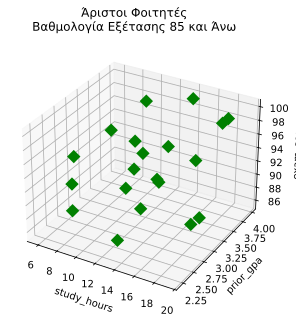

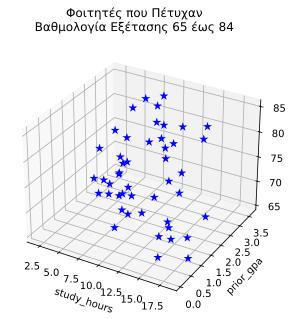

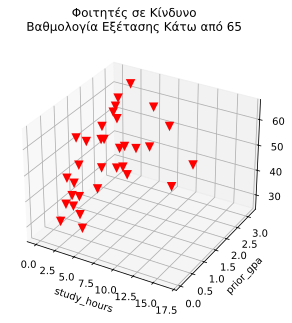

In [6]:
footnote j=r 'Από μια ομάδα 100 συνθετικών φοιτητών ';

/* Άριστοι (exam_score >= 85): πράσινοι ρόμβοι */
TITLE 'Άριστοι Φοιτητές';
title2 'Βαθμολογία Εξέτασης 85 και Άνω';
ΔΙΑΔΙΚΑΣΙΑ g3d ΔΕΔΟΜΕΝΑ=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=green shape=diamond size=3
           noneedle grid zmin=0 zmax=100
           name="band_honors"
           description="Άριστοι φοιτητές";
   ΟΠΟΥ BAND = 'Άριστοι';
   ΕΤΙΚΕΤΑ study_hours = 'Εβδομαδιαίες Ώρες Μελέτης'
         prior_gpa   = 'Προηγούμενος GPA'
         exam_score  = 'Βαθμολογία Τελικής Εξέτασης';
ΕΚΤΕΛΕΣΗ;
QUIT;

/* Επιτυχόντες (65 <= exam_score < 85): μπλε τρέφλες */
TITLE 'Φοιτητές που Πέτυχαν';
title2 'Βαθμολογία Εξέτασης 65 έως 84';
ΔΙΑΔΙΚΑΣΙΑ g3d ΔΕΔΟΜΕΝΑ=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=blue shape=club size=3
           noneedle grid zmin=0 zmax=100
           name="band_pass"
           description="Φοιτητές που πέτυχαν";
   ΟΠΟΥ BAND = 'Επιτυχόντες';
   ΕΤΙΚΕΤΑ study_hours = 'Εβδομαδιαίες Ώρες Μελέτης'
         prior_gpa   = 'Προηγούμενος GPA'
         exam_score  = 'Βαθμολογία Τελικής Εξέτασης';
ΕΚΤΕΛΕΣΗ;
QUIT;

/* Σε Κίνδυνο (exam_score < 65): κόκκινα μπαστούνια */
TITLE 'Φοιτητές σε Κίνδυνο';
title2 'Βαθμολογία Εξέτασης Κάτω από 65';
ΔΙΑΔΙΚΑΣΙΑ g3d ΔΕΔΟΜΕΝΑ=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=red shape=spade size=3
           noneedle grid zmin=0 zmax=100
           name="band_atrisk"
           description="Φοιτητές σε κίνδυνο";
   ΟΠΟΥ BAND = 'Σε Κίνδυνο';
   ΕΤΙΚΕΤΑ study_hours = 'Εβδομαδιαίες Ώρες Μελέτης'
         prior_gpa   = 'Προηγούμενος GPA'
         exam_score  = 'Βαθμολογία Τελικής Εξέτασης';
ΕΚΤΕΛΕΣΗ;
QUIT;


## Βήμα 7 — Ξεχωριστά διαγράμματα διασποράς ανά ομάδα εισαγωγής (ομάδα BY)

Οι υπεύθυνοι προγράμματος συχνά χρειάζονται την ίδια προβολή χωρισμένη ανά ομάδα εισαγωγής. Η
δήλωση **BY** παράγει μία διασπορά ανά ομάδα εισαγωγής. Το G3D αναμένει τα δεδομένα ομάδας BY να
είναι ταξινομημένα, οπότε ταξινομούμε πρώτα με το PROC SORT. Κάθε ομάδα εισαγωγής λαμβάνει τότε
τη δική της επισημασμένη τρισδιάστατη διασπορά σε κοινό άξονα βαθμολογίας 0–100, καθιστώντας τις
κατανομές Φθινοπώρου και Άνοιξης εύκολα συγκρίσιμες η μία δίπλα στην άλλη.


                                       Αποτελέσματα Εξετάσεων ανά Ομάδα Εισαγωγής                                       
                           Μία Τρισδιάστατη Διασπορά ανά Ομάδα Εισαγωγής (Φθινόπωρο, Άνοιξη)                            

PROC G3D Output
Data: students_sorted

Variables: student_id, Ομάδα Εισαγωγής, Εβδομαδιαίες Ώρες Μελέτης, Προηγούμενος GPA, Βαθμολογία Τελικής Εξέτασης, Ομάδα Επίδοσης

student_id                Ομάδα Εισαγωγής                         Εβδομαδιαίες Ώρες Μελέτης              Προηγούμενος GPA                           Βαθμολογία Τελικής Εξέτασης               Ομάδα Επίδοσης
----------  -----------------------------  ------------------------------------------------  ----------------------------  ----------------------------------------------------  ---------------------------
        53                         Άνοιξη                                     10.7875369915                  3.0789706431                                         76.6136428341   


NOTE: PROC SORT data=students

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from students.
NOTE: Wrote students_sorted (100 rows, 6 columns).
NOTE: PROC SORT statement used.
NOTE: Option TITLE changed to Αποτελέσματα Εξετάσεων ανά Ομάδα Εισαγωγής.
NOTE: Option TITLE2 changed to Μία Τρισδιάστατη Διασπορά ανά Ομάδα Εισαγωγής (Φθινόπωρο, Άνοιξη).
NOTE: Option FOOTNOTE changed to Ένα πάνελ ανά ομάδα εισαγωγής .
NOTE: PROC G3D data=students_sorted

NOTE: ODS plot written: cohort_scatter_by1.spec.json
NOTE: ODS plot written: cohort_scatter_by2.spec.json


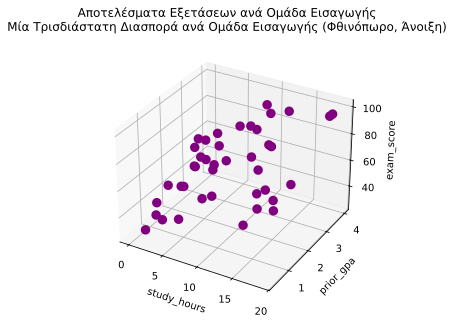

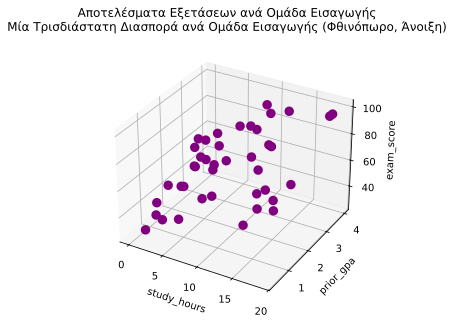

In [7]:
ΔΙΑΔΙΚΑΣΙΑ ΤΑΞΙΝΟΜΗΣΗ ΔΕΔΟΜΕΝΑ=students out=students_sorted;
   ΚΑΤΑ cohort;
ΕΚΤΕΛΕΣΗ;

TITLE 'Αποτελέσματα Εξετάσεων ανά Ομάδα Εισαγωγής';
title2 'Μία Τρισδιάστατη Διασπορά ανά Ομάδα Εισαγωγής (Φθινόπωρο, Άνοιξη)';
footnote j=r 'Ένα πάνελ ανά ομάδα εισαγωγής ';

ΔΙΑΔΙΚΑΣΙΑ g3d ΔΕΔΟΜΕΝΑ=students_sorted;
   ΚΑΤΑ cohort;
   SCATTER prior_gpa*study_hours=exam_score /
           color=purple
           shape=balloon
           size=3
           grid
           zmin=0 zmax=100
           name="cohort_scatter";
   ΕΤΙΚΕΤΑ study_hours = 'Εβδομαδιαίες Ώρες Μελέτης'
         prior_gpa   = 'Προηγούμενος GPA'
         exam_score  = 'Βαθμολογία Τελικής Εξέτασης';
ΕΚΤΕΛΕΣΗ;
QUIT;


## Βήμα 8 — Εστίαση στην περιοχή κινδύνου με WHERE

Για τον σχεδιασμό παρέμβασης, η πιο αξιοποιήσιμη προβολή είναι η κάτω αριστερή γωνία της
επιφάνειας: φοιτητές με μέτριο χρόνο μελέτης (8 ώρες ή λιγότερο) και χαμηλότερο προηγούμενο GPA
(2,5 ή λιγότερο). Η δήλωση **WHERE** περιορίζει τη διασπορά σε αυτή την περιοχή πριν από τη
σχεδίαση. Η λίστα δείχνει ότι αυτή η γωνία περιέχει 35 από τους 100 φοιτητές — 22 από αυτούς ήδη
*Σε Κίνδυνο* — ώστε οι σύμβουλοι να μπορούν να δουν ακριβώς ποιοι δυσκολευόμενοι φοιτητές
βρίσκονται πιο μακριά κάτω από την προσδοκία.


                             Εστίαση Παρέμβασης: Φοιτητές Χαμηλής Προσπάθειας, Χαμηλού GPA                              
                                         study_hours <= 8 και prior_gpa <= 2.5                                          

PROC G3D Output
Data: students

Variables: student_id, Ομάδα Εισαγωγής, Εβδομαδιαίες Ώρες Μελέτης, Προηγούμενος GPA, Βαθμολογία Τελικής Εξέτασης, Ομάδα Επίδοσης

student_id                Ομάδα Εισαγωγής                         Εβδομαδιαίες Ώρες Μελέτης              Προηγούμενος GPA                           Βαθμολογία Τελικής Εξέτασης               Ομάδα Επίδοσης
----------  -----------------------------  ------------------------------------------------  ----------------------------  ----------------------------------------------------  ---------------------------
         1                      Φθινόπωρο                                      4.9780700766                   1.072086769                                          59.409228777          


NOTE: Option TITLE changed to Εστίαση Παρέμβασης: Φοιτητές Χαμηλής Προσπάθειας, Χαμηλού GPA.
NOTE: Option TITLE2 changed to study_hours <= 8 και prior_gpa <= 2.5.
NOTE: Option FOOTNOTE changed to Οι κατακόρυφες γραμμές ρίχνουν κάθε δείκτη στο δάπεδο ωρών μελέτης x GPA .
NOTE: PROC G3D data=students

NOTE: ODS plot written: g3d_scatter.spec.json


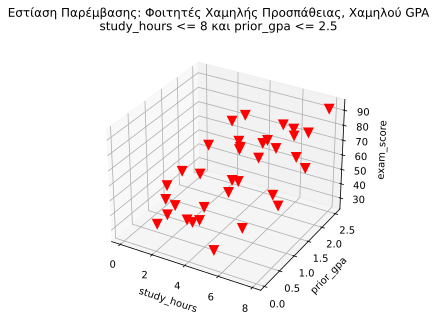

In [8]:
TITLE 'Εστίαση Παρέμβασης: Φοιτητές Χαμηλής Προσπάθειας, Χαμηλού GPA';
title2 'study_hours <= 8 και prior_gpa <= 2.5';
footnote j=r 'Οι κατακόρυφες γραμμές ρίχνουν κάθε δείκτη στο δάπεδο ωρών μελέτης x GPA ';

ΔΙΑΔΙΚΑΣΙΑ g3d ΔΕΔΟΜΕΝΑ=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=red
           shape=spade
           size=4
           grid
           zmin=0 zmax=100;
   ΟΠΟΥ study_hours <= 8 AND prior_gpa <= 2.5;
   ΕΤΙΚΕΤΑ study_hours = 'Εβδομαδιαίες Ώρες Μελέτης'
         prior_gpa   = 'Προηγούμενος GPA'
         exam_score  = 'Βαθμολογία Τελικής Εξέτασης';
ΕΚΤΕΛΕΣΗ;
QUIT;


## Ερμηνεία των Αποτελεσμάτων

Η **επιφάνεια απόκρισης** (Βήματα 2–4) δείχνει μια σαφή κορεσμένη κορυφογραμμή. Σε όλο το πλέγμα
99 κελιών η προβλεπόμενη βαθμολογία κυμαίνεται από περίπου 26 (μηδέν ώρες μελέτης, μηδέν GPA) έως
περίπου 99 (η γωνία υψηλών ωρών, υψηλού GPA), με μέσο όρο πλέγματος κοντά στο 70. Διαβάζοντας κατά
μήκος του άξονα ωρών μελέτης, οι βαθμολογίες ανεβαίνουν απότομα από το 0 προς περίπου 10 ώρες και
στη συνέχεια ισοπεδώνονται καθώς οι επιπλέον ώρες αποδίδουν φθίνουσες αποδόσεις· διαβάζοντας κατά
μήκος του άξονα GPA, η προηγούμενη επίδοση μετατοπίζει ολόκληρη την επιφάνεια προς τα πάνω. Ο
όρος αλληλεπίδρασης κάνει την απόδοση των ωρών μελέτης λίγο πιο απότομη για ισχυρότερους
φοιτητές, γι' αυτό η επιφάνεια γέρνει προς τη μακρινή της γωνία αντί να ανεβαίνει ως επίπεδο
επίπεδο.

Τα **πάνελ φοιτητών** (Βήματα 6–7) επιβεβαιώνουν ότι το μοντέλο ισχύει για τα άτομα. Η ομάδα των
100 χωρίζεται σε 20 *Άριστους*, 47 *Επιτυχόντες*, και 33 *Σε Κίνδυνο* φοιτητές. Στα πάνελ ομάδων,
οι 20 πράσινοι ρόμβοι *Άριστων* — ο καθένας με βαθμολογία 85 ή περισσότερο — βρίσκονται σε
προηγούμενο GPA 2,2 ή υψηλότερο και τουλάχιστον περίπου 6 εβδομαδιαίες ώρες μελέτης, συγκεντρωμένοι
στην πάνω δεξιά γωνία του επιπέδου δαπέδου. Οι 33 κόκκινοι δείκτες *Σε Κίνδυνο* συγκεντρώνονται
στην περιοχή χαμηλής προσπάθειας, χαμηλού GPA, ακριβώς στην κοιλάδα της επιφάνειας. Ο διαχωρισμός
ανά ομάδα εισαγωγής δείχνει ότι οι κατανομές Φθινοπώρου (41 φοιτητές) και Άνοιξης (59 φοιτητές)
είναι ευρέως παρόμοιες, υποδηλώνοντας ότι τα αποτελέσματα οδηγούνται από τους δύο παράγοντες και
όχι από τον χρόνο εισαγωγής.

Η **προβολή φιλτραρισμένη με WHERE** (Βήμα 8) απομονώνει τον πληθυσμό παρέμβασης: τους 35
φοιτητές με 8 ή λιγότερες ώρες μελέτης και GPA 2,5 ή χαμηλότερο. Είκοσι δύο είναι ήδη *Σε
Κίνδυνο* και μόνο ένας φτάνει στους *Άριστους*. Μέσα σε αυτή τη γωνία οι πραγματοποιημένες
βαθμολογίες εξακολουθούν να ανεβαίνουν ορατά με τις ώρες μελέτης — ένα συγκεκριμένο, οπτικό
επιχείρημα ότι μέτριες αυξήσεις στον δομημένο χρόνο μελέτης προσφέρουν τα μεγαλύτερα οριακά οφέλη
ακριβώς εκεί όπου χρειάζονται περισσότερο.

Συνολικά, το PROC G3D μετατρέπει ένα μοντέλο αλληλεπίδρασης δύο παραγόντων σε μια διαισθητική,
έτοιμη-για-απόφαση εικόνα για ένα εκπαιδευτικό πρόγραμμα: πού βρίσκεται το ανώτατο όριο
βαθμολογίας, ποιος υπολείπεται από αυτό, και πού η προσπάθεια καθοδήγησης θα αποδώσει
περισσότερο.

> **Σημείωση υλοποίησης.** Το SAS/GRAPH επιτρέπει επίσης σε μία μόνο δήλωση SCATTER να χρωματίζει
> και να διαμορφώνει κάθε δείκτη από μεταβλητές ανά παρατήρηση (`COLOR=<charvar>`,
> `SHAPE=<charvar>`). Αυτή η μορφή ανά παρατήρηση δεν αποδίδεται ακόμα σε αυτή τη μηχανή, οπότε
> αυτό το notebook σχεδιάζει αντ' αυτού ένα πάνελ με κυριολεκτικό χρώμα ανά ομάδα — μια ισοδύναμη,
> πλήρως λειτουργική παρουσίαση. Το κενό παρακολουθείται από τη δοκιμασία παλινδρόμησης
> `tests/401000_nb_g3d_scatter_color_variable_unrendered`.
